#**스마트폰 센서 데이터 기반 모션 분류**
# 단계3 : 단계별 모델링


## 0.미션4

* 단계별로 나눠서 모델링을 수행하고자 합니다.  
* 단계 구분 예시
    * 단계1 : 정적(0), 동적(1) 행동 분류 모델 생성
    * 단계2 : 세부 동작에 대한 분류모델 생성
        * 단계1 모델에서 0으로 예측 -> 정적 행동 3가지 분류 모델링
        * 단계1 모델에서 1으로 예측 -> 동적 행동 3가지 분류 모델링
* 모델 통합
    * 두 단계 모델을 통합하고, 새로운 데이터에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
* 성능 비교
    * 기본 모델링의 성능과 비교
    * 성능 가이드
        * Accuracy : 0.97 ~ 0.99
* 파이프라인 구성
    * test 데이터를 입력하여, 전처리 및 예측결과가 나오도록 함수 구성

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/project3/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam

In [4]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [5]:
trainData = pd.read_csv(path + 'data01_train.csv')
testData = pd.read_csv(path + 'data01_test.csv')

In [6]:
trainData.drop(columns=['subject'], inplace=True)
testData.drop(columns=['subject'], inplace=True)

In [7]:
testData.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.509523,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.210792,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.579587,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.566291,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.447577,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,STANDING


#### 2) 기본 정보 조회

In [8]:
trainData.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


In [9]:
trainData.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [10]:
testData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 6.3+ MB


In [11]:
testData.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,...,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000,1471.000000
mean,0.273198,-0.017281,-0.108123,-0.614634,-0.515427,-0.607533,-0.639950,-0.530760,-0.609256,-0.481055,...,0.118651,-0.311513,-0.632273,0.009324,0.015666,0.006272,-0.001510,-0.481737,0.055771,-0.064194
std,0.079989,0.045957,0.049082,0.448480,0.506094,0.424243,0.422994,0.489381,0.418536,0.542756,...,0.258112,0.313792,0.296179,0.324864,0.452616,0.608954,0.483028,0.522714,0.298124,0.281645
min,-1.000000,-1.000000,-0.418354,-0.999717,-0.999873,-1.000000,-0.999867,-1.000000,-0.999879,-0.948723,...,-1.000000,-0.995357,-0.994664,-0.937468,-0.990492,-0.995222,-0.969066,-0.999380,-0.995073,-1.000000
25%,0.263787,-0.024792,-0.120733,-0.992669,-0.979082,-0.981070,-0.993498,-0.979214,-0.980659,-0.936791,...,-0.035193,-0.546342,-0.844547,-0.119166,-0.265533,-0.485998,-0.380300,-0.814060,-0.017413,-0.148445
50%,0.277322,-0.017187,-0.108124,-0.952426,-0.867309,-0.869890,-0.958705,-0.873891,-0.863451,-0.890491,...,0.135282,-0.347433,-0.706699,0.005049,0.023421,-0.005036,0.002408,-0.708911,0.178814,-0.002243
75%,0.288058,-0.010238,-0.096606,-0.245405,-0.030639,-0.260223,-0.297260,-0.058824,-0.256657,-0.030692,...,0.289832,-0.125796,-0.516910,0.135698,0.312690,0.518184,0.374583,-0.486534,0.248126,0.096674
max,0.631510,0.359587,0.543939,0.899922,0.782590,0.931308,0.950758,0.602458,0.784041,0.821218,...,0.860512,0.941113,0.894210,0.980889,0.991899,0.994366,0.979522,1.000000,0.432496,0.992766


## 2.데이터 전처리

* 세부 요구사항
    - Label 추가 : 1단계 모델을 위한 레이블 추가
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

### (1) 1단계 모델링을 위한 레이블

### (2) x, y 분리

In [12]:
trainData['is_dynamic'] = trainData['Activity'].apply(lambda x: 0 if x in ['STANDING', 'SITTING', 'LAYING'] else 1)

In [13]:
target = 'is_dynamic'
x = trainData.drop(columns=[target, 'Activity'])
y = trainData[target]

### (3) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [14]:
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

In [15]:
le = LabelEncoder()
y = le.fit_transform(y)

### (4) 데이터 분할
* train, val 분할

In [16]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

## **3.단계별 모델링**

### (1) 단계1

* 세부 요구사항
    * 적절한 단계로 구분한 후, 1단계를 분류하는 모델 생성
        * 예시 : 정적 행동(Laying, Sitting, Standing)과 동적 행동(동적 : Walking, Walking-Up, Walking-Down)을 구분하는 모델 생성.
    * 몇 가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

#### 1) 모델1

In [17]:
nfeatures = x_train.shape[1]
nfeatures

561

In [18]:
il = Input(shape=(nfeatures,))
x = Dense(256, activation='relu')(il)
ol = Dense(1, activation='sigmoid')(x)

model1 = Model(inputs = il, outputs = ol)
model1.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001))

In [19]:
hist = model1.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history

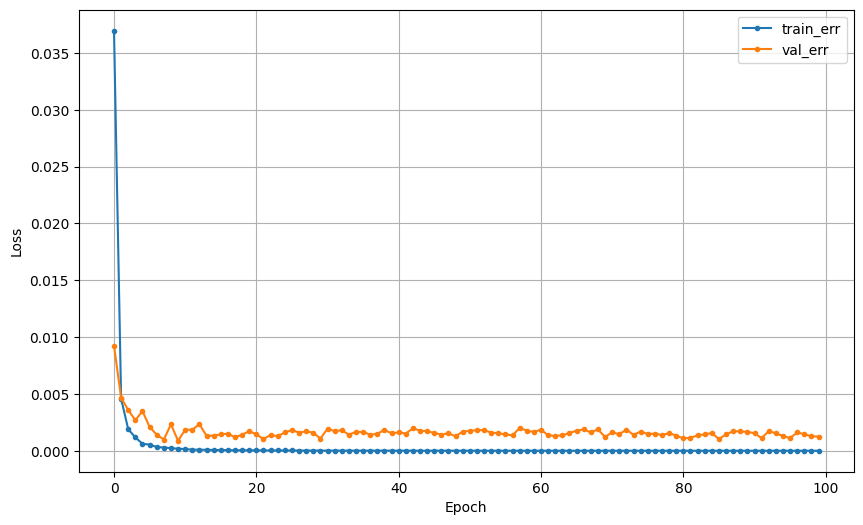

In [20]:
dl_history_plot(hist)

In [21]:
pred = model1.predict(x_val)
pred = np.where(pred>0.5, 1, 0)
print(classification_report(y_val, pred))

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       657
           1       1.00      1.00      1.00       520

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177



#### 2) 모델2

In [22]:
il = Input(shape=(nfeatures,))
ol = Dense(1, activation='sigmoid')(il)

model2 = Model(inputs = il, outputs = ol)
model2.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001))

In [23]:
hist = model2.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history

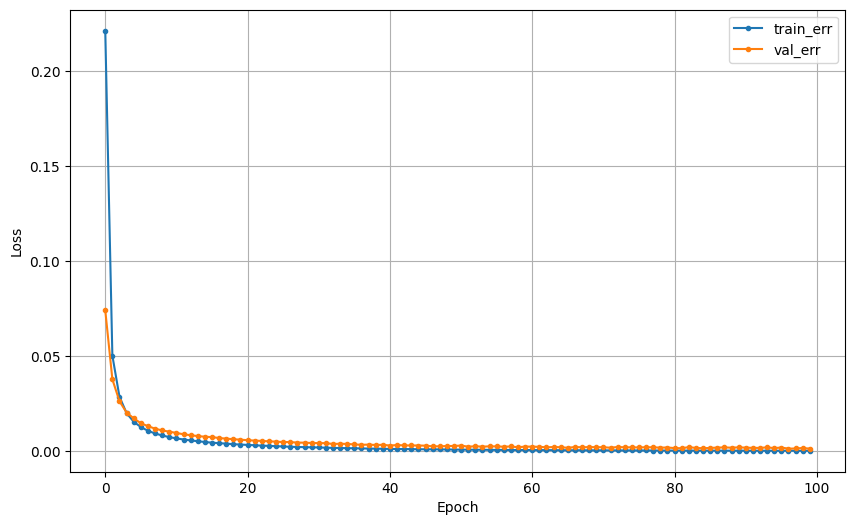

In [24]:
dl_history_plot(hist)

In [25]:
pred = model2.predict(x_val)
pred = np.where(pred>0.5, 1, 0)
print(classification_report(y_val, pred))

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       657
           1       1.00      1.00      1.00       520

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177



In [26]:
def iterate(il, ol):
  result = {}
  for i in range(5):
    clear_session()
    model = Model(inputs = il, outputs = ol)
    model.compile(optimizer= Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy')
    hist1 = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history
    pred1 = model.predict(x_val)
    pred_1 = pred1.argmax(axis=1)
    result[i] = accuracy_score(y_val, pred_1)
  print(np.mean(list(result.values())))
  print(result)

### (2) 단계2

#### 1) 단계2-1 : 정적 동작 세부 분류

* 세부 요구사항
    * 정적 행동(Laying, Sitting, Standing)인 데이터 추출
    * Laying, Sitting, Standing 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [27]:
data1 = trainData.loc[trainData['is_dynamic'] == 0]

In [28]:
data1.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity,is_dynamic
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING,0
7,0.272026,-0.001329,-0.125491,-0.992068,-0.912985,-0.972451,-0.994752,-0.943141,-0.976428,-0.925446,...,-0.704995,-0.024442,0.076332,0.741277,0.729812,-0.817201,0.037746,0.136129,STANDING,0
8,0.284338,0.021956,-0.006925,-0.980153,-0.838394,-0.782357,-0.983683,-0.816199,-0.743923,-0.914011,...,-0.400197,0.021212,-0.009465,-0.282762,0.563343,-0.782072,0.242834,-0.025285,STANDING,0


In [29]:
target = ['Activity', 'is_dynamic']
x = data1.drop(columns=target)
y = data1['Activity']

In [30]:
le = LabelEncoder()
y = le.fit_transform(y)

In [31]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
nfeatures = x_train.shape[1]
nfeatures

561

In [33]:
from keras.callbacks import EarlyStopping

In [34]:
il = Input(shape=(nfeatures,))
x = Dense(512, activation='relu')(il)
x = Dropout(0.3)(x)
x = Dense(356, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(236, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(106, activation='relu')(x)
x = Dense(56, activation='relu')(x)
ol = Dense(3, activation='softmax')(x)


model3 = Model(inputs = il, outputs = ol)
model3.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0001))

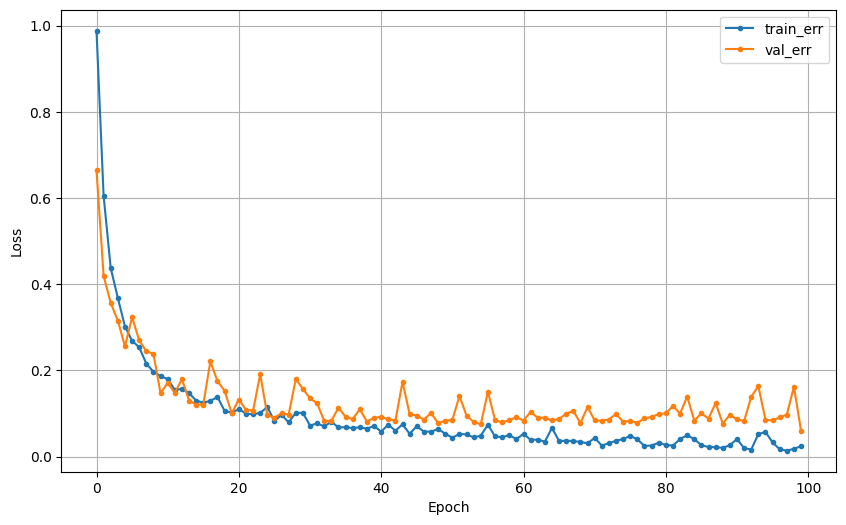

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
[[221   0   0]
 [  0 200   5]
 [  0  14 207]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.93      0.98      0.95       205
           2       0.98      0.94      0.96       221

    accuracy                           0.97       647
   macro avg       0.97      0.97      0.97       647
weighted avg       0.97      0.97      0.97       647



In [35]:
hist = model3.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history
dl_history_plot(hist)
pred1 = model3.predict(x_val)
pred_1 = pred1.argmax(axis=1)
print(confusion_matrix(y_val, pred_1))
print(classification_report(y_val, pred_1))

#### 2) 단계2-2 : 동적 동작 세부 분류

* 세부 요구사항
    * 동동적 행동(Walking, Walking Upstairs, Walking Downstairs)인 데이터 추출
    * Walking, Walking Upstairs, Walking Downstairs 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [36]:
data2 = trainData.loc[trainData['is_dynamic'] == 1]
data2['is_dynamic'] = data2['is_dynamic'].map({3:0, 4:1, 5:2})
target = ['Activity', 'is_dynamic']
x = data2.drop(columns=target)
y = data2['Activity']
le = LabelEncoder()
y = le.fit_transform(y)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

<ipython-input-36-51b92f6b6169>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['is_dynamic'] = data2['is_dynamic'].map({3:0, 4:1, 5:2})


In [37]:
il = Input(shape=(nfeatures,))
x = Dense(512, activation='relu')(il)
x = Dropout(0.3)(x)
x = Dense(356, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(236, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(106, activation='relu')(x)
x = Dense(56, activation='relu')(x)
ol = Dense(3, activation='softmax')(x)

model4 = Model(inputs = il, outputs = ol)
model4.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0001))

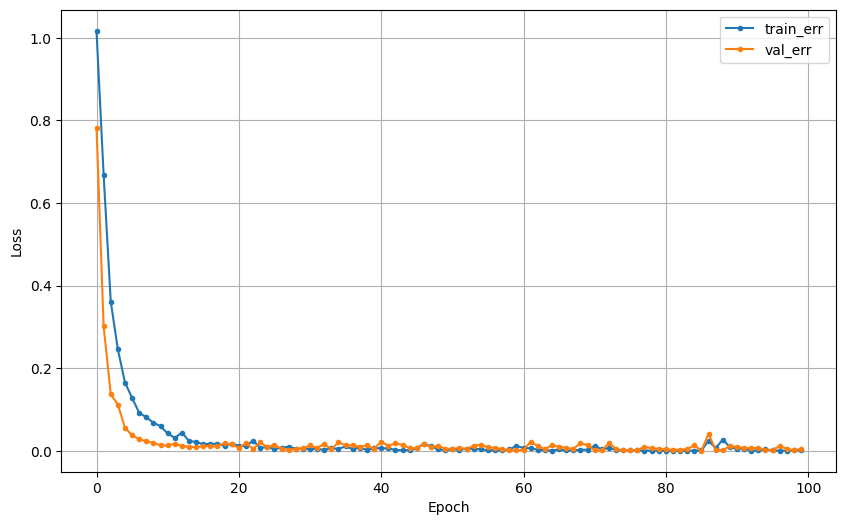

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
[[195   0   1]
 [  0 163   0]
 [  1   0 170]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       196
           1       1.00      1.00      1.00       163
           2       0.99      0.99      0.99       171

    accuracy                           1.00       530
   macro avg       1.00      1.00      1.00       530
weighted avg       1.00      1.00      1.00       530



In [38]:
hist = model4.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history
dl_history_plot(hist)
pred1 = model4.predict(x_val)
pred_1 = pred1.argmax(axis=1)
print(confusion_matrix(y_val, pred_1))
print(classification_report(y_val, pred_1))

### (3) 분류 모델 파이프라인 구성


* 세부 요구사항
    * 두 단계 모델을 통합하고, 새로운 데이터(test)에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
    * 데이터 파이프라인 구축 : test데이터가 로딩되어 전처리 과정을 거치고, 예측 및 성능 평가 수행

* 예시
![](https://github.com/DA4BAM/image/blob/main/pipeline%20function.png?raw=true)

#### 1) 함수 만들기

In [78]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def process_test_data(test, model1, model2_1, model2_2):
    # 동적/정적 구분하는 'is_dynamic' 열 추가
    test['is_dynamic'] = np.where(test['Activity'].isin(['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']), 1, 0)

    # 테스트 데이터셋을 x_test와 y_test로 분리
    x_test = test.drop(['Activity', 'is_dynamic', 'subject'], axis=1)
    y_test_array = test['Activity'].map({
        'LAYING': 0,
        'SITTING': 1,
        'STANDING': 2,
        'WALKING': 3,
        'WALKING_UPSTAIRS': 4,
        'WALKING_DOWNSTAIRS': 5
    }).values

    # x_test에 학습 데이터와 동일한 스케일러 적용
    scaler = MinMaxScaler()
    x_test = scaler.fit_transform(x_test)

    # 모델 1을 사용하여 동적/정적 데이터 예측
    pred_test = model1.predict(x_test)
    pred_test_label = np.where(pred_test > 0.5, 1, 0)  # 0 또는 1로 변환

    # 예측값이 1(동적)인 데이터와 0(정적)인 데이터로 각각 분리
    index_1 = np.where(pred_test_label.flatten() == 1)[0]  # 예측이 1인 데이터의 인덱스
    index_0 = np.where(pred_test_label.flatten() == 0)[0]  # 예측이 0인 데이터의 인덱스

    x_test_1 = x_test[index_1]  # 동적 데이터
    x_test_0 = x_test[index_0]  # 정적 데이터

    # 정적 데이터에 대해 model2_1을 사용하여 예측
    pred_test_0 = model2_1.predict(x_test_0)
    pred_test_label_0 = np.argmax(pred_test_0, axis=1)  # LAYING, SITTING, STANDING 예측 (0, 1, 2)

    # 동적 데이터에 대해 model2_2를 사용하여 예측
    pred_test_1 = model2_2.predict(x_test_1)
    pred_test_label_1 = np.argmax(pred_test_1, axis=1)  # WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS 예측 (0, 1, 2)

    # 동적 모델 예측 값 변환: 0 -> WALKING(3), 1 -> WALKING_UPSTAIRS(4), 2 -> WALKING_DOWNSTAIRS(5)
    pred_test_label_1_encoded = np.where(pred_test_label_1 == 0, 3,  # 0 -> 3
                                         np.where(pred_test_label_1 == 1, 4,  # 1 -> 4
                                                  np.where(pred_test_label_1 == 2, 5, -1)))  # 2 -> 5

    # 원래 y_test_array와 같은 크기의 빈 배열 생성
    pred_test_labels = np.empty_like(y_test_array)

    # 각 인덱스에 맞춰 예측 결과를 삽입
    pred_test_labels[index_1] = pred_test_label_1_encoded  # 동적 예측 결과
    pred_test_labels[index_0] = pred_test_label_0  # 정적 예측 결과
    print(pred_test_label_1[pred_test_label_1 == 2].shape)

    print(y_test_array)
    # y_test와 예측값 비교
    accuracy = accuracy_score(y_test_array, pred_test_labels)

    # Confusion Matrix 및 Classification Report 출력
    cm = confusion_matrix(y_test_array, pred_test_labels)
    cr = classification_report(y_test_array, pred_test_labels, target_names=[
        'LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'
    ])

    # 결과 반환
    return accuracy, cm, cr

#### 2) test 셋으로 예측하고 평가하기

In [79]:
# 사용 예시
# 데이터 로드
test_data=pd.read_csv(path + 'data01_test.csv')

# 함수 호출
accuracy, cm, cr = process_test_data(test_data, model1, model3, model4)

# 결과 출력
print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(cm)
print('Classification Report:')
print(cr)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
(9,)
[1 2 3 ... 5 0 5]
Accuracy: 0.7403127124405167
Confusion Matrix:
[[281   7   3   0   1   0]
 [  0 220  34   0   0   0]
 [  0  10 277   0   0   0]
 [  0   0   0 207  21   0]
 [  0   0   0 102 104   9]
 [  0   0   0   2 193   0]]
Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      0.96      0.98       292
           SITTING       0.93      0.87      0.90       254
          STANDING       0.88      0.97      0.92       287
           WALKING       0.67      0.91      0.77       228
  WALKING_UPSTAIRS       0.33      0.48      0.39       215
WALKING_DOWNSTAIRS       0.00      0.00      0.00       195

          accuracy                           0.74      1471
         macro avg       0.63      0.70      0.66      1471
      weighted avg       0.68      0.74      0.71      1471

